In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pointbiserialr, chi2_contingency
from sklearn.preprocessing import LabelEncoder
from scipy.stats import f_oneway


In [17]:
# Load dataset
df = pd.read_csv("LapGenSurgOnly_2022.csv", low_memory=False)


# Define features
TARGET_FEATURES = ['CDARREST', 'CDMI', 'PULEMBOL', 'REINTUB', 'OUPNEUMO', 'FAILWEAN']
INPUT_FEATURES = [
    "Age", "SEX", "RACE_NEW", "BMI", "INOUT", "ASACLAS", "CPT",
    "DIABETES", "SMOKE", "FNSTATUS2", "HXCOPD", "ASCITES", "HXCHF", "HYPERMED",
    "DIALYSIS", "DISCANCR", "STEROID", "TRANSFUS"
]

continuous_feats = ['Age', 'BMI']
categorical_feats = [feat for feat in INPUT_FEATURES if feat not in continuous_feats]

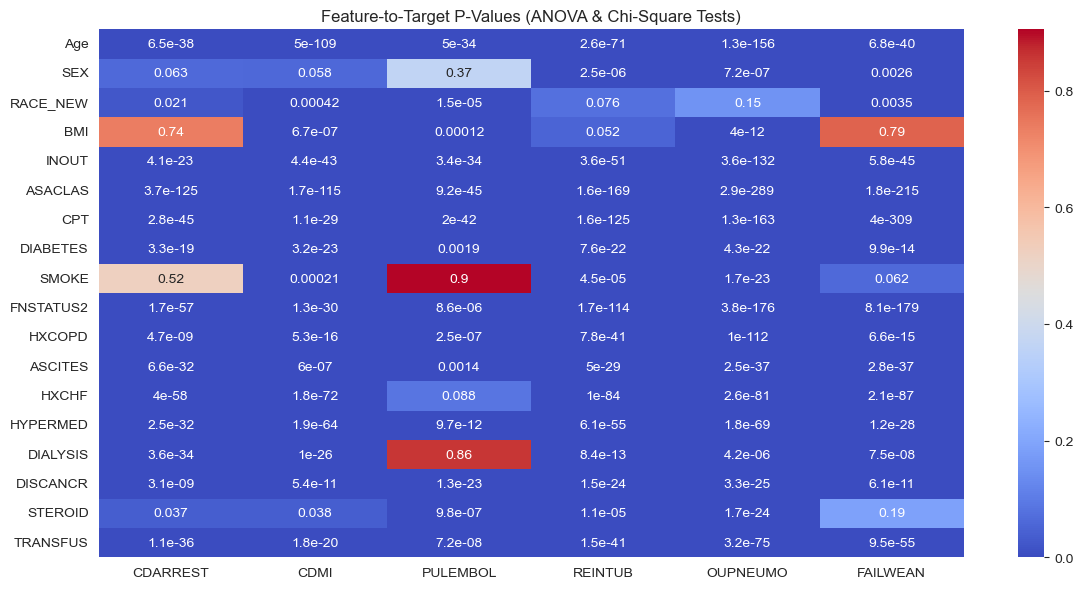

In [12]:

# Encode categorical features
df_encoded = df[INPUT_FEATURES + TARGET_FEATURES].copy()
le_dict = {}
for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    le_dict[col] = le

# Cramér’s V for categorical features
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    if n == 0:
        return np.nan
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    if min(r, k) == 1:
        return np.nan  # Avoid division by zero
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denominator = min((kcorr - 1), (rcorr - 1))
    if denominator <= 0:
        return np.nan
    return np.sqrt(phi2corr / denominator)


# Define continuous features manually
continuous_feats = ['Age', 'BMI']
# P-value matrix instead of correlation
pvalue_matrix = pd.DataFrame(index=INPUT_FEATURES, columns=TARGET_FEATURES)

for feature in INPUT_FEATURES:
    for target in TARGET_FEATURES:
        if feature in continuous_feats:
            try:
                # ANOVA test
                groups = [df_encoded[df_encoded[target] == val][feature].dropna()
                          for val in df_encoded[target].unique()]
                if len(groups) > 1:
                    f_stat, p_val = f_oneway(*groups)
                else:
                    p_val = np.nan
            except:
                p_val = np.nan
        else:
            try:
                contingency_table = pd.crosstab(df_encoded[feature], df_encoded[target])
                _, p_val, _, _ = chi2_contingency(contingency_table)
            except:
                p_val = np.nan
        pvalue_matrix.loc[feature, target] = p_val

pvalue_matrix = pvalue_matrix.astype(float)

# Plot the heatmap of p-values
plt.figure(figsize=(12, 6))
sns.heatmap(pvalue_matrix, annot=True, cmap="coolwarm", fmt=".2g")
plt.title("Feature-to-Target P-Values (ANOVA & Chi-Square Tests)")
plt.tight_layout()
plt.show()


# 3.3 Statistical Association: ANOVA and Chi-Square P-Value Analysis
# 
# To assess the statistical association between each input feature and the six binary postoperative outcomes, we conducted univariate significance tests and visualized the resulting p-values in a heatmap (Figure~\ref{fig:pval_heatmap}). Specifically, we applied the Chi-Square test of independence for categorical input features and one-way ANOVA for continuous features. The features considered included both demographic and clinical variables, while the target outcomes consisted of six postoperative complications: cardiac arrest (CDARREST), myocardial infarction (CDMI), pulmonary embolism (PULEMBOL), unplanned intubation (REINTUB), pneumonia (OUPNEUMO), and failure to wean from ventilation (FAILWEAN).
# 
# The results reveal that a majority of input features demonstrated statistically significant associations (p < 0.05) with at least one postoperative outcome. Notably, features such as INOUT status, ASA classification, CPT code, functional status (FNSTATUS2), and transfusion requirement (TRANSFUS) exhibited highly significant associations (p < 0.001) across all outcomes, underscoring their relevance in perioperative risk profiling.
# 
# Continuous variables like Age and BMI displayed differential significance patterns. While Age was consistently and strongly associated with all six outcomes (e.g., p = 6.5×10⁻³⁸ for CDARREST), BMI failed to reach significance in several cases, such as for CDARREST (p = 0.74) and FAILWEAN (p = 0.79), suggesting limited univariate predictive utility.
# 
# In contrast, certain categorical variables showed weak or non-significant associations. Smoking status (SMOKE), for instance, was not significantly associated with CDARREST (p = 0.52) or PULEMBOL (p = 0.90). Similarly, DIALYSIS and SEX did not exhibit statistically robust relationships with multiple outcomes, raising questions about their individual predictive strength in isolation.
# 
# These findings provided an initial filtering mechanism to prioritize variables for subsequent multivariate modeling. Features with consistently low p-values across multiple outcomes were retained for further importance ranking and interaction analysis in later stages of this study.


        count       mean        std        min        25%        50%  \
Age  210349.0  52.462593  17.590861  18.000000  38.000000  53.000000   
BMI  210349.0  30.760272   7.775820   7.373689  25.328579  29.342344   

           75%        max  skewness  kurtosis  
Age  66.000000   90.00000 -0.071986 -0.931056  
BMI  34.724658  181.90125  1.206144  3.104325  


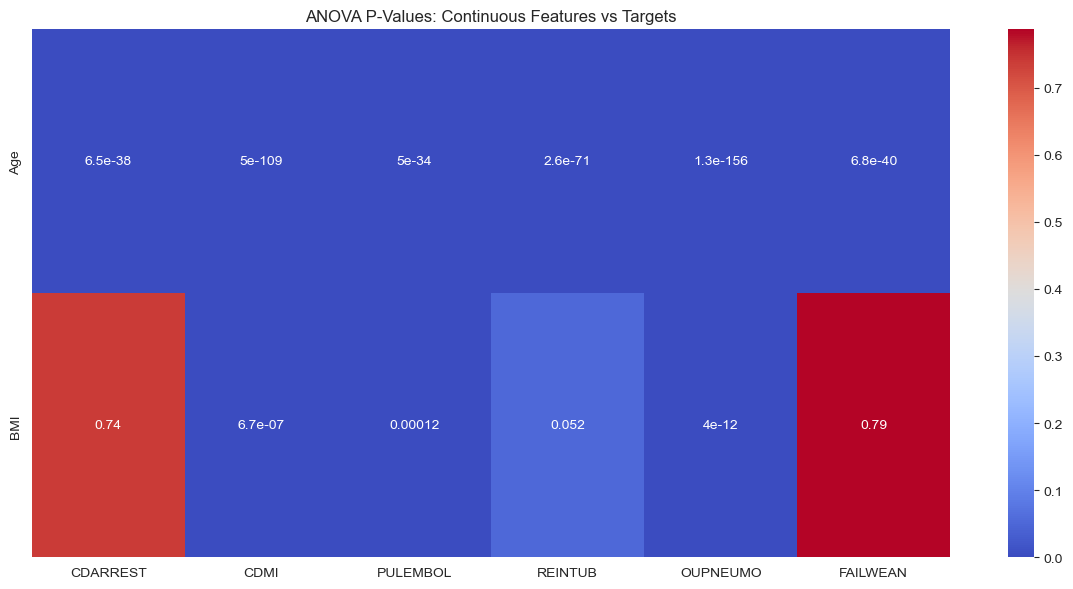

In [18]:
# # 3 Exploratory Data Analysis
# 
# This section presents a structured exploratory analysis of the dataset. We begin by summarizing the continuous variables using descriptive statistics, followed by univariate association tests to assess the statistical significance of each feature with respect to the binary outcomes. We then examine the independence of categorical variables and conclude with a collinearity analysis using a correlation matrix.
# 
# ## 3.1 Continuous Univariate Analysis
# 
# We report summary statistics for continuous features, including mean, standard deviation, skewness, and kurtosis. Additionally, one-way ANOVA tests are conducted to determine if the means of continuous variables differ significantly across outcome categories.
# 
# ### 3.1.1 Descriptive Statistics
summary = df[continuous_feats].describe().T
summary["skewness"] = df[continuous_feats].skew()
summary["kurtosis"] = df[continuous_feats].kurtosis()
print(summary)

# ### 3.1.2 ANOVA: Association with Target Variables
# 
# To test whether the continuous variables vary significantly across target outcomes, one-way ANOVA was applied. The resulting p-values are displayed in a matrix and visualized below.

from scipy.stats import f_oneway

pvalue_matrix = pd.DataFrame(index=INPUT_FEATURES, columns=TARGET_FEATURES)

for feature in INPUT_FEATURES:
    for target in TARGET_FEATURES:
        if feature in continuous_feats:
            try:
                groups = [df_encoded[df_encoded[target] == val][feature].dropna()
                          for val in df_encoded[target].unique()]
                if len(groups) > 1:
                    f_stat, p_val = f_oneway(*groups)
                else:
                    p_val = np.nan
            except:
                p_val = np.nan
        else:
            continue  # Categorical handled in next section
        pvalue_matrix.loc[feature, target] = p_val

pvalue_matrix = pvalue_matrix.astype(float)


# Heatmap of ANOVA p-values (continuous only)
plt.figure(figsize=(12, 6))
sns.heatmap(pvalue_matrix.loc[continuous_feats], annot=True, cmap="coolwarm", fmt=".2g")
plt.title("ANOVA P-Values: Continuous Features vs Targets")
plt.tight_layout()
plt.show()


Feature: SEX
             Count Proportion
SEX                          
female      113796     54.10%
male         96446     45.85%
non-binary     107      0.05%
Cardinality: 3
Missing Rate: 0.00%

Feature: RACE_NEW
                            Count Proportion
RACE_NEW                                    
White                      137404     65.32%
Unknown/Not Reported        37828     17.98%
Black or African American   17650      8.39%
Asian                        8390      3.99%
Other                        7984      3.80%
Mixed                        1093      0.52%
Cardinality: 6
Missing Rate: 0.00%

Feature: INOUT
             Count Proportion
INOUT                        
Inpatient   109732     52.17%
Outpatient  100617     47.83%
Cardinality: 2
Missing Rate: 0.00%

Feature: ASACLAS
                   Count Proportion
ASACLAS                            
2-Mild Disturb    102024     48.50%
3-Severe Disturb   84090     39.98%
1-No Disturb       18222      8.66%
4-Life Threat     

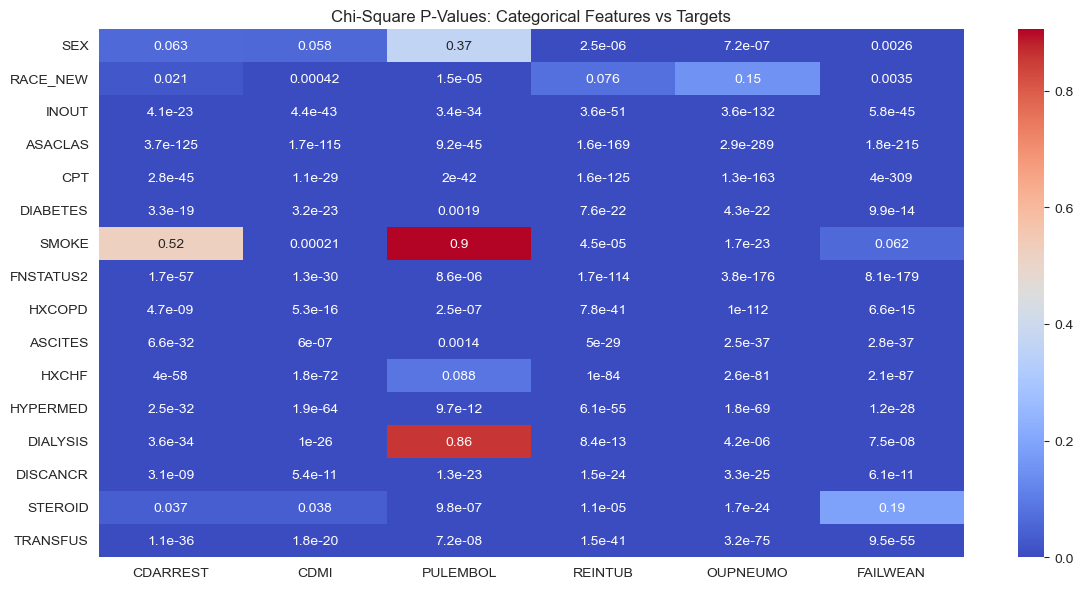

In [19]:
# ## 3.2 Categorical Univariate Analysis
# 
# Categorical features were evaluated using frequency analysis and Chi-square tests of independence to assess statistical association with each binary outcome.
# 
# ### 3.2.1 Frequency and Cardinality Summary

for col in categorical_feats:
    print(f"\nFeature: {col}")
    vc = df[col].value_counts(dropna=False)
    rf = vc / len(df)
    print(pd.DataFrame({
        "Count": vc,
        "Proportion": rf.map("{:.2%}".format)
    }).head(10))
    print(f"Cardinality: {df[col].nunique()}")
    print(f"Missing Rate: {df[col].isnull().mean():.2%}")
    
# ### 3.2.2 Chi-Square Test of Independence
# 
# Chi-square tests were performed for each categorical feature-outcome pair.

for feature in categorical_feats:
    for target in TARGET_FEATURES:
        try:
            contingency_table = pd.crosstab(df_encoded[feature], df_encoded[target])
            _, p_val, _, _ = chi2_contingency(contingency_table)
        except:
            p_val = np.nan
        pvalue_matrix.loc[feature, target] = p_val
        
        
# Heatmap of p-values for categorical features
plt.figure(figsize=(12, 6))
sns.heatmap(pvalue_matrix.loc[categorical_feats], annot=True, cmap="coolwarm", fmt=".2g")
plt.title("Chi-Square P-Values: Categorical Features vs Targets")
plt.tight_layout()
plt.show()

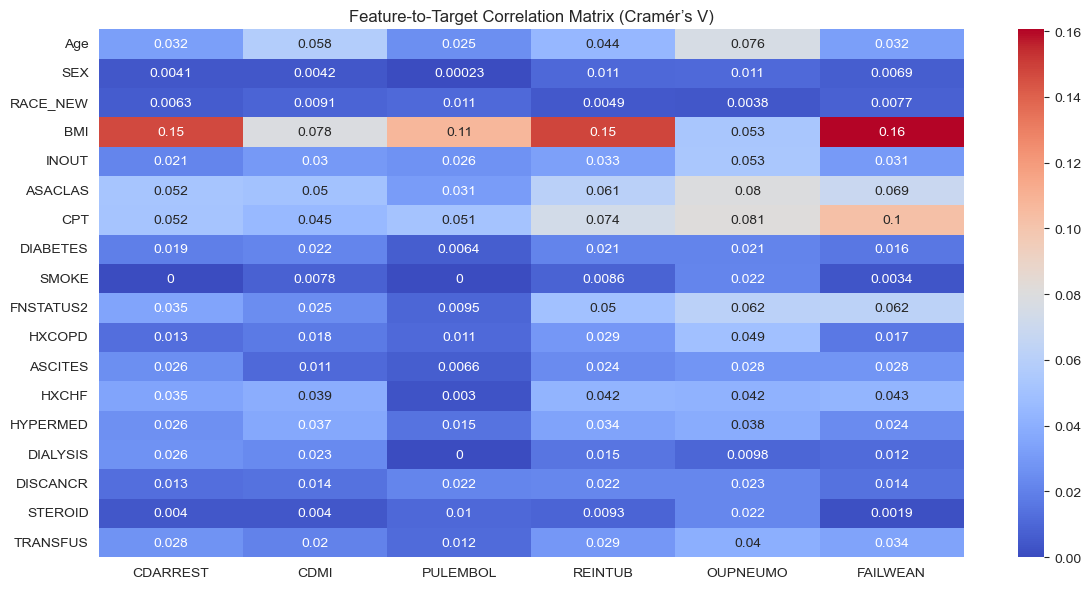

In [20]:
# ## 3.3 Collinearity Analysis
# 
# To examine potential multicollinearity, a feature correlation matrix was computed using Point-Biserial correlation for binary-continuous pairs and Cramér’s V for categorical pairs.

# Cramér’s V helper
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

# Correlation matrix for categorical vs target
correlation_matrix = pd.DataFrame(index=INPUT_FEATURES, columns=TARGET_FEATURES)

for feature in INPUT_FEATURES:
    for target in TARGET_FEATURES:
        try:
            contingency = pd.crosstab(df_encoded[feature], df_encoded[target])
            correlation_matrix.loc[feature, target] = cramers_v(contingency.values)
        except:
            correlation_matrix.loc[feature, target] = np.nan

correlation_matrix = correlation_matrix.astype(float)


plt.figure(figsize=(12, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2g")
plt.title("Feature-to-Target Correlation Matrix (Cramér’s V)")
plt.tight_layout()
plt.show()



In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Select features for VIF (excluding target)
X = df_encoded[INPUT_FEATURES].copy()

# Standardize features
X_scaled = StandardScaler().fit_transform(X)

# Create DataFrame for VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))

      Feature       VIF
0         Age  1.611087
5     ASACLAS  1.560149
13   HYPERMED  1.465799
3         BMI  1.228622
4       INOUT  1.212923
6         CPT  1.170057
7    DIABETES  1.148210
12      HXCHF  1.074112
10     HXCOPD  1.061722
1         SEX  1.037782
8       SMOKE  1.033049
9   FNSTATUS2  1.030872
15   DISCANCR  1.030396
14   DIALYSIS  1.028396
16    STEROID  1.022646
2    RACE_NEW  1.021993
17   TRANSFUS  1.015479
11    ASCITES  1.010384
